# Deviation models in SuperKludge

This notebook follows on from `basic_few.ipynb`. That notebook introduced `SuperKludgeFlux` and its `add_args` with the deviation switched off. Here we switch it on and look at:

0. the LISA response (TDI channels A, E, T) and the noise-weighted inner product used later,
1. what the deviation parameters are and how they enter the equations of motion,
2. how to switch them on (and how to check that zero deviation gives back GR),
3. their effect on the fluxes $\dot p$, $\dot e$ at fixed $(p, e)$,
4. their effect on trajectories: dephasing over time, scaling with the coefficient, and a comparison with the size of the 1PA terms,
5. their effect on $p_0$ for a fixed observation time,
6. their effect on the TDI waveforms (noise-weighted mismatch),
7. a systematic-bias study: fitting a 1PA injection with a 0PA + deviation template using an iterated Cutler–Vallisneri / Levenberg–Marquardt climb.

Throughout, **"GR"** means the SuperKludge model with the same `chi2` and PN flags as the deviation run, but with every deviation coefficient zero. That way every difference we plot comes only from the deviation.

## 0. Setup

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

import few
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import SuperKludgeFlux
from few.waveform import GenerateEMRIWaveform, SuperKludgeWaveform
from few.utils.utility import get_p_at_t
from few.utils.constants import YRSID_SI

# LISA response, noise model and Fisher tools
from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product, fishinv
from stableemrifisher.fisher import StableEMRIFisher

print("few imported from:", few.__file__)  # must be SuperKludge_r/src

use_gpu = True   # True on the GPU node
if use_gpu:
    import cupy as xp
else:
    xp = np

cfg_set = few.get_config_setter(reset=True)
cfg_set.enable_backends("cuda12x" if use_gpu else "cpu")
cfg_set.set_log_level("info")

to_float = lambda x: float(x.get()) if hasattr(x, "get") else float(x)  # cupy/numpy scalar -> float

few imported from: /home/svu/e1583490/packages_to_install/SuperKludge_r/src/few/__init__.py


In [24]:
# Fiducial source (same as basic_few.ipynb)
m1, m2, a = 1e6, 10.0, 0.9                    # masses [M_sun], primary spin
e0, x0 = 0.2, 1.0                             # initial eccentricity, prograde equatorial
dist = 1.0                                    # [Gpc]
qS, phiS, qK, phiK = np.pi / 3, np.pi / 4, np.pi / 5, np.pi / 6
Phi_phi0, Phi_theta0, Phi_r0 = 0.1, 0.2, 0.3
T, dt = 1.0, 10.0                             # [yr], [s]

eta = m1 * m2 / (m1 + m2) ** 2                # the "massratio" used inside SuperKludgeFlux
print(f"eta = {eta:.3e}")

# SuperKludge flags, fixed for the whole notebook
chi2 = 0.6
evolve_1PA, evolve_primary, evolve_2PA = True, False, True

traj = EMRIInspiral(func=SuperKludgeFlux)

eta = 1.000e-05


### 0.1 Response wrapper and TDIs

Time Delay Interferometry (TDI) is the standard technique for suppressing the laser noise in LISA data. It subtracts delayed phase measurements from different spacecraft, removing the overwhelming laser noise so that the weak GW signals buried in the instrumental noise can be analysed. For simplicity we assume a static LISA configuration with equal and constant arm lengths. The Michelson-like TDI streams $\{X, Y, Z\}$ can then be rotated into the $\{A, E, T\}$ basis. For a static LISA, the noise in $A$, $E$ and $T$ is uncorrelated, so the noise covariance is diagonal and the Whittle likelihood is cheap to evaluate. The EMRI response is computed with `fastlisaresponse`, which can run on the GPU.

In code, `ResponseWrapper` wraps a FEW waveform generator. It is called with the same arguments as the waveform (14 parameters + `add_args`) and returns the three TDI channels $[A, E, T]$ instead of $h_+ - i h_\times$. The same settings are used in `~/EMRI_CV_bias`, including `tdi="1st generation"`. We can also use TDI 2nd generation which use `tdi="2nd generation"` and `A2TDISens, E2TDISens, T2TDISens` instead of `A1TDISens, E1TDISens, T1TDISens.`

With the channels in hand we define the **noise-weighted inner product**

$$
\langle a|b\rangle = 4\,\mathrm{Re}\sum_{\alpha\in\{A,E,T\}} \int_{f_{\min}}^{f_{\rm Nyq}} \frac{\tilde a_\alpha^*(f)\,\tilde b_\alpha(f)}{S_\alpha(f)}\,df, \qquad \mathrm{SNR} = \sqrt{\langle h|h\rangle},
$$

which is used for the mismatch in Section 6 and for the bias study in Section 7.

In [25]:
def response_kwargs(T, dt):
    """fastlisaresponse settings: equal-arm orbits, 1st-generation TDI, A/E/T channels for now"""
    return dict(
        Tobs=T, dt=dt,
        t0=10000.0,                    # [s] data at the start/end affected by the TDI delays
        remove_garbage="zero",         # ... is zeroed rather than cut if it plunges sooner than Tobs
        index_lambda=8, index_beta=7,  # positions of phiS and qS among the 14 waveform parameters
        is_ecliptic_latitude=False,    # qS is a polar angle, not a latitude
        flip_hx=True,                  # FEW returns h+ - i hx
        orbits=EqualArmlengthOrbits(force_backend="cuda12x" if use_gpu else "cpu"),  # must match force_backend below
        order=20,                      # interpolation order of the projection
        tdi="1st generation", tdi_chan="AET",
        force_backend="cuda12x" if use_gpu else "cpu",
    )

channels = [A1TDISens, E1TDISens, T1TDISens]            # noise model of each TDI channel
noise_kwargs = [{"sens_fn": ch} for ch in channels]

def make_tdi_generator(T, dt):
    """SuperKludge waveform -> LISA response. Call it like the waveform; returns [A, E, T]."""
    wave = GenerateEMRIWaveform(SuperKludgeWaveform, return_list=False,
                                sum_kwargs=dict(pad_output=True, odd_len=True))
    return ResponseWrapper(waveform_gen=wave, **response_kwargs(T, dt))  ## we ResponseWrapper for fastlisaresponse, which is a wrapper for the LISA response
# this always projection from the waveform to the TDI channels, and it is fast because it uses GPU if available

T_resp = 1
sk_tdi = make_tdi_generator(T_resp, dt)

Generate the GR signal in the three channels, build the PSD on the same frequency grid, and check the SNR in each channel. The $T$ channel is insensitive to GWs at low frequency, so its SNR should be essentially **zero**. A large $T$-channel SNR means the signal has power above the Nyquist frequency $1/(2\,dt)$ that is aliasing back into the band; if you see it, reduce `dt`. This happened for the IMRI ($m_2 = 10^3$) grid at `dt=10` in `EMRI_CV_bias`. One of the important check is to see the distribution of SNR in each channels and be careful about ZEROs in the PSD. We will talk about it more as we progress.

In simple language, cadence or delta t decides which is the larget frequency we can resolve

total SNR = 282.87
  SNR_A = 163.1
  SNR_E = 146.4
  SNR_T = 178.8


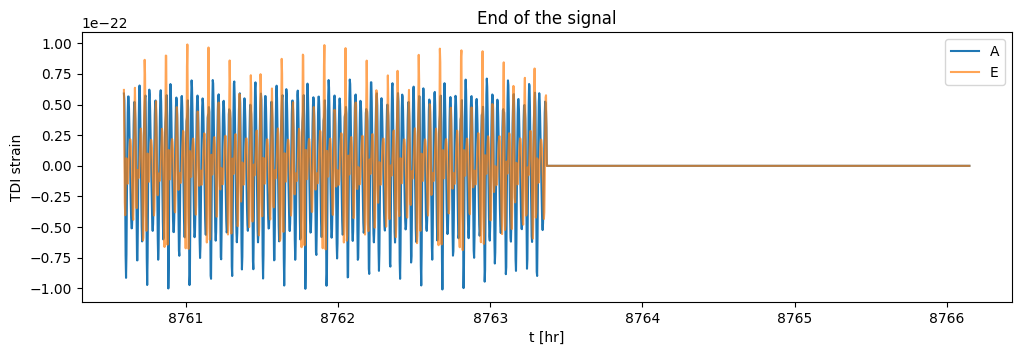

In [26]:
# GR signal: 1PA + 2PA, no deviation
add_args_gr = [chi2, evolve_1PA, evolve_primary, evolve_2PA, False]
p0_resp = get_p_at_t(traj, T_resp, [m1, m2, a, e0, x0, *add_args_gr]) + 0.1
params_resp = [m1, m2, a, p0_resp, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

tdi_gr = xp.asarray(sk_tdi(*params_resp, *add_args_gr))          # shape (3, N): A, E, T

# PSD of each channel, and the noise-weighted inner product <a|b> for f > 1e-5 Hz
# we are using generate PSD method from SEF.
#Basically, in frequency domain, at each frequency, we assume the noise is Gaussian and uncorrelated between channels
#  with variance given by the PSD. and this PSD infornmation is used to compute the inner product between two signals,
#  which is a measure of how similar they are in the presence of noise.
# we are getting PSF from the sensitivity function of each channel, which is a function of frequency and
#  describes how sensitive the detector is to gravitational waves at different frequencies.
psd = xp.asarray(generate_PSD(waveform=tdi_gr, dt=dt, noise_PSD=get_sensitivity,
                              channels=channels, noise_kwargs=noise_kwargs, use_gpu=use_gpu))
fmask = (xp.fft.rfftfreq(tdi_gr.shape[-1], dt) > 1e-5)[1:]
#just to clarify, the fmask is a boolean array that masks out frequencies below 1e-5 Hz, 
# which are not considered in the inner product calculation. As it is beyond
#  the sensitivity of LISA, we are not interested in those frequencies. Also, ideally it would contribute
#  very little to the inner product, so we can also ignore the masking.

#small helper functions to compute the inner product and SNR of the TDI signals
def ip(a, b):
    return to_float(inner_product(a, b, PSD=psd, dt=dt, freq_mask=fmask, use_gpu=use_gpu))

def only(h, k):
    """Keep channel k of a TDI array and zero the others."""
    return h * (xp.arange(3)[:, None] == k)
#

print(f"total SNR = {np.sqrt(ip(tdi_gr, tdi_gr)):.2f}")
for k, name in enumerate("AET"):
    print(f"  SNR_{name} = {np.sqrt(ip(only(tdi_gr, k), only(tdi_gr, k))):.4g}")

A, E = (tdi_gr[:2].get() if use_gpu else tdi_gr[:2])
t_hr = np.arange(A.size) * dt / 3600
plt.figure(figsize=(12, 3.5))
plt.plot(t_hr[-2000:], A[-2000:], label="A")
plt.plot(t_hr[-2000:], E[-2000:], label="E", alpha=0.7)
plt.xlabel("t [hr]"); plt.ylabel("TDI strain"); plt.title("End of the signal"); plt.legend(); plt.show()

## 1. The deviation parametrization

`SuperKludgeFlux` has two independent families of deviation parameters. Both are read by position from `add_args` (indices 5–8) and are only active when `deviation_included = True` (index 4):

| Index | Name | Family | Enters as |
|---|---|---|---|
| 4 | `deviation_included` | master switch | if `False`, all four coefficients are set to zero whatever you pass |
| 5 | `C_p` | additive | extra term in $\dot p$ motivated by the leading-order PN form at 1PA. (0PN-1PA)|
| 6 | `C_e` | additive | extra term in $\dot e$. Same (0PN-1PA)|
| 7 | `del_0_p` | multiplicative | rescales the 1PA adiabatic as massratio multiplied by 0PA term |
| 8 | `del_0_e` | multiplicative | rescales the 1PA adiabatic as massratio multiplied by 0PA term|

### 1.1 PN-informed Deviation: `C_p`, `C_e`

These are added in `SuperKludgeFlux.modify_rhs`, after the Jacobian (which basically converts from E,L,Q to p,e,x) and then p and e are modified as follows:
$$
\dot p \;\mathrel{+}=\; \eta\, C_p\,(1-e^2)^{3/2}\,\frac{8+7e^2}{p^{7/2}}, \qquad
\dot e \;\mathrel{+}=\; \eta\, C_e\, e\,(1-e^2)^{3/2}\,\frac{304+121e^2}{p^{9/2}}.
$$

Compare them with the leading-order (Peters–Mathews) GR fluxes, in units $G=c=m_1=1$ and with the overall mass-ratio factor removed, as in the FEW ODE right-hand side:

$$
\dot p_{\rm PM} = -\frac{8}{5}\,(1-e^2)^{3/2}\,\frac{8+7e^2}{p^{3}}, \qquad
\dot e_{\rm PM} = -\frac{1}{15}\, e\,(1-e^2)^{3/2}\,\frac{304+121e^2}{p^{4}}.
$$

The deviation terms have **the same eccentricity dependence** as the leading GR fluxes, with an extra $p^{-1/2}$ and an overall factor $\eta$:

$$
\frac{\dot p_{\rm dev}}{\dot p_{\rm PM}} = -\frac{5}{8}\,\frac{\eta\, C_p}{\sqrt p}, \qquad
\frac{\dot e_{\rm dev}}{\dot e_{\rm PM}} = -15\,\frac{\eta\, C_e}{\sqrt p}.
$$

So:
* they are **$\mathcal{O}(\eta)$ relative to the adiabatic fluxes**, i.e. the same order as the 1PA terms, and
* **positive** $C_p$ ($C_e$) **reduces** $|\dot p|$ ($|\dot e|$), which slows the inspiral (the circularisation). Negative values speed it up.

### 1.2 Simple Deviation: `del_0_p`, `del_0_e`

These are applied in `SuperKludgeFlux.evaluate_rhs` to the interpolated **0PA** fluxes only:

$$
\dot p_{0\rm PA} \to (1+\eta\,\delta_{0,p})\,\dot p_{0\rm PA}, \qquad
\dot e_{0\rm PA} \to (1+\eta\,\delta_{0,e})\,\dot e_{0\rm PA}.
$$

This is a uniform fractional change of size $\eta\,\delta_0$ at every $(p, e)$. Again it is $\mathcal{O}(\eta)$, i.e. 1PA-sized. Positive $\delta_0$ **increases** $|\dot p|$ or $|\dot e|$, which is the opposite sign convention to $C_p$ and $C_e$.

> **Note:** the class docstring says `del_0_p` and `del_0_e` rescale $\dot E$ and $\dot L$. With the default `flux_output_convention="pex"` of `KerrEccEqFlux`, however, the interpolant returns $(\dot p, \dot e)$ directly and no Jacobian is applied. The variables named `Edot` and `Ldot` in `evaluate_rhs` therefore hold $\dot p$ and $\dot e$. Section 3 confirms this numerically: `del_0_p` changes only $\dot p$, and `del_0_e` changes only $\dot e$. (ignore for now). But basically there is a wrong variable notation in flux.py where E_dot (Energy_dot) and L_dot (momentum_dot) actually stands for p_dot and e_dot.

### 1.3 Building `add_args`

A small helper that turns on the master switch only when a coefficient is non-zero:

In [27]:
def dev_args(C_p=0.0, C_e=0.0, del_0_p=0.0, del_0_e=0.0, deviation_included=None):
    """SuperKludge add_args with this notebook's chi2/PN flags and the given deviation coefficients."""
    if deviation_included is None:                       # switch on only if something is non-zero
        deviation_included = any(c != 0.0 for c in (C_p, C_e, del_0_p, del_0_e))
    return [chi2, evolve_1PA, evolve_primary, evolve_2PA, deviation_included,
            C_p, C_e, del_0_p, del_0_e]

args_gr = dev_args()
print("GR         :", args_gr)
print("C_p = 1    :", dev_args(C_p=1.0))

GR         : [0.6, True, False, True, False, 0.0, 0.0, 0.0, 0.0]
C_p = 1    : [0.6, True, False, True, True, 1.0, 0.0, 0.0, 0.0]


## 2. Switching deviations on, and recovering GR

Three checks on the master switch:
1. `deviation_included=True` with all coefficients zero must give the GR trajectory.
2. `deviation_included=False` must **ignore** non-zero coefficients.
3. A missing entry defaults to zero, so a shorter list such as `[chi2, 1PA, primary, 2PA, True, C_p]` is valid.

In [28]:
max_step_size = 1.0 * 24 * 3600   # 1 day: dense, smooth trajectories for taking differences
p0 = get_p_at_t(traj, T, [m1, m2, a, e0, x0, *args_gr]) + 0.1   # no plunge within T
print(f"p0 = {p0:.4f}")

def run(add_args, p0=p0, T=T):
    """SuperKludge trajectory of the fiducial source -> (t, p, e, x, Phi_phi, Phi_theta, Phi_r, dm1, da)."""
    return traj(m1, m2, a, p0, e0, x0, *add_args,
                Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
                T=T, max_step_size=max_step_size)

gr = run(args_gr)

# each of these must reproduce GR exactly
checks = {
    "switch on, zero coefficients": dev_args(deviation_included=True),
    "switch off, C_p = 5 ignored":  dev_args(C_p=5.0, deviation_included=False),
    "short list, C_p = 0":          [chi2, evolve_1PA, evolve_primary, evolve_2PA, True, 0.0],
}
for label, add_args in checks.items():
    out = run(add_args)
    print(f"{label:30s}: max |Phi_phi - Phi_phi_GR| = {np.max(np.abs(out[4] - gr[4])):.2e}")

p0 = 7.2544
switch on, zero coefficients  : max |Phi_phi - Phi_phi_GR| = 0.00e+00
switch off, C_p = 5 ignored   : max |Phi_phi - Phi_phi_GR| = 0.00e+00
short list, C_p = 0           : max |Phi_phi - Phi_phi_GR| = 0.00e+00


## 3. Effect on the fluxes at fixed $(p, e)$

Before integrating anything, it is useful to see how much each coefficient changes $\dot p$ and $\dot e$ at a given point. We evaluate the ODE right-hand side of `SuperKludgeFlux` directly and plot the fractional change relative to GR, divided by $\eta$ so that the numbers are $\mathcal{O}(1)$. The dashed lines are the analytic predictions from Section 1.

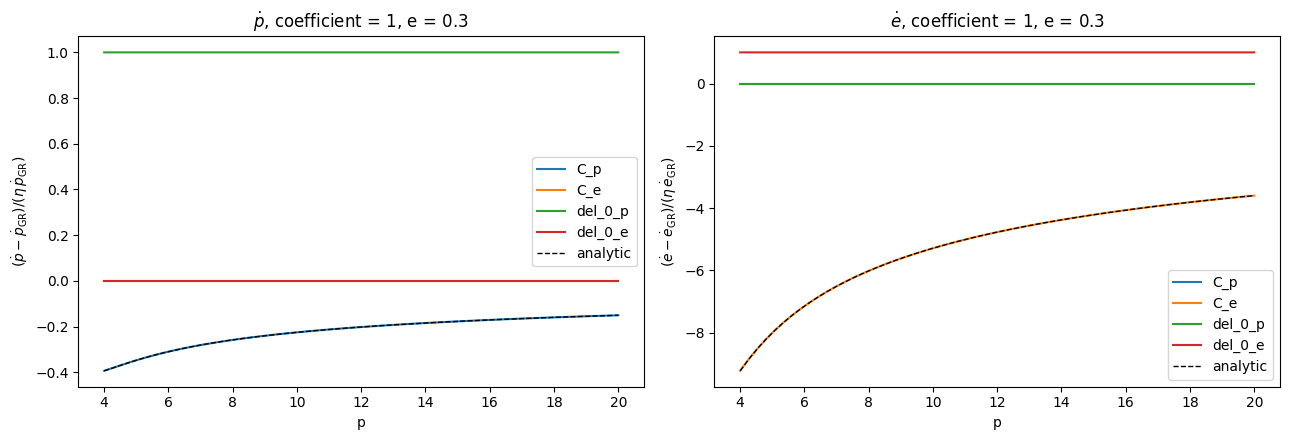

In [29]:
flux = SuperKludgeFlux()

def rhs(add_args, p, e):  # this is the right-hand side of the ODE for p and e, given the deviation arguments and the current values of p and e
    """Right-hand side of the ODE at (p, e): returns (pdot, edot) for the fiducial m1, m2, a."""
    flux.add_fixed_parameters(m1, m2, a, additional_args=add_args)
    out = flux(np.array([p, e, x0, 0.0, 0.0, 0.0, 0.0, 0.0]))   # state: p, e, x, 3 phases, dm1, da
    return out[0], out[1]

e_eval = 0.3
p_grid = np.linspace(4.0, 20.0, 60)
coeffs = {"C_p": dev_args(C_p=1.0), "C_e": dev_args(C_e=1.0),
          "del_0_p": dev_args(del_0_p=1.0), "del_0_e": dev_args(del_0_e=1.0)}

# fractional change of (pdot, edot) w.r.t. GR, in units of eta
gr_flux = np.array([rhs(args_gr, p, e_eval) for p in p_grid])                  # (len(p_grid), 2)
frac = {name: (np.array([rhs(args, p, e_eval) for p in p_grid]) - gr_flux) / gr_flux / eta
        for name, args in coeffs.items()}

# analytic prediction for the additive terms (per unit coefficient)
pdot_pred = (1 - e_eval**2) ** 1.5 * (8 + 7 * e_eval**2) / p_grid**3.5 / gr_flux[:, 0]
edot_pred = e_eval * (1 - e_eval**2) ** 1.5 * (304 + 121 * e_eval**2) / p_grid**4.5 / gr_flux[:, 1]

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for k, (ax, pred, q) in enumerate(zip(axs, [pdot_pred, edot_pred], ["p", "e"])):
    for name in coeffs:
        ax.plot(p_grid, frac[name][:, k], label=name)
    ax.plot(p_grid, pred, "k--", lw=1, label="analytic")
    ax.set(xlabel="p", ylabel=rf"$(\dot {q} - \dot {q}_{{\rm GR}}) / (\eta\,\dot {q}_{{\rm GR}})$",
           title=rf"$\dot {q}$, coefficient = 1, e = {e_eval}")
    ax.legend()
plt.tight_layout()
plt.show()

What to take from this:
* `del_0_p` and `del_0_e` give a flat fractional change of exactly $\eta\,\delta_0$ in one flux only.
* `C_p` and `C_e` give a **negative** fractional change, i.e. a smaller $|\dot p|$ or $|\dot e|$, and it grows towards small $p$. Close to the separatrix, where most of the signal-to-noise and dephasing accumulate, the effect is strongest.
* For the same coefficient value, `C_e` changes $\dot e$ roughly 20 times more than `C_p` changes $\dot p$ (the factors $15$ vs $5/8$ in Section 1). The coefficients of the two families are therefore not directly comparable in size.

## 4. Effect on trajectories

### 4.1 Dephasing over time

For each coefficient we integrate the same source with a single non-zero coefficient and compare it with GR on a common time grid. The last point sits on the separatrix (or at $T$) and is dropped.

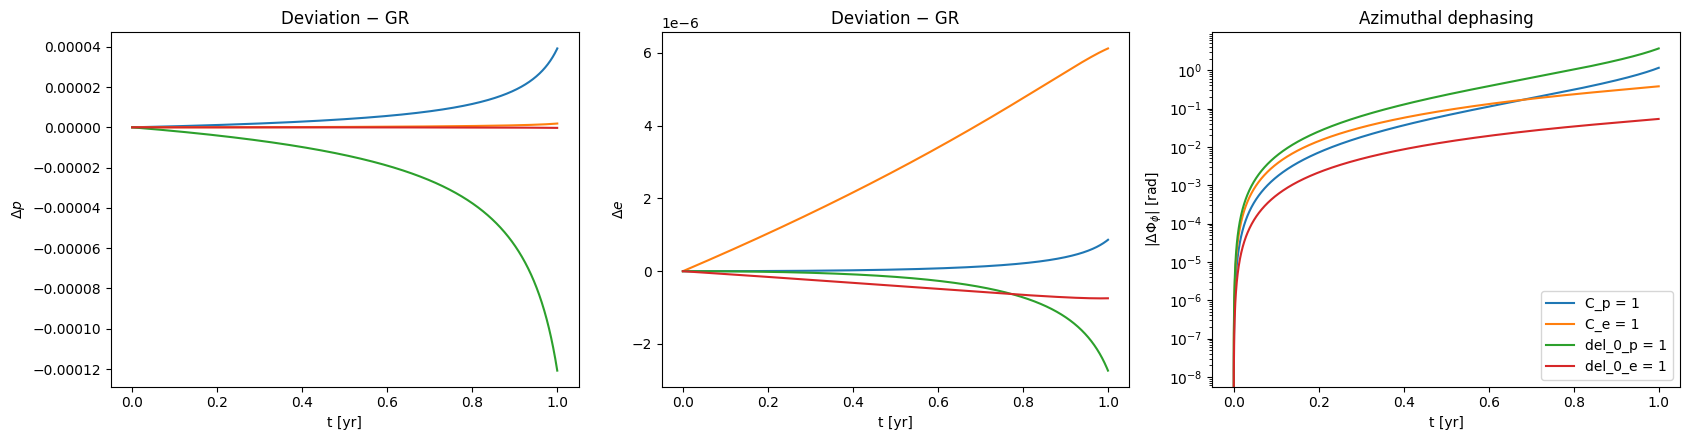

In [30]:
def dephasing(traj_a, traj_b, n=2000):
    """(b - a) on a common time grid -> t, Delta p, Delta e, Delta Phi_phi, Delta Phi_r."""
    ta, tb = traj_a[0], traj_b[0]
    t = np.linspace(max(ta[0], tb[0]), min(ta[-2], tb[-2]), n)   # drop the last (separatrix) point
    diff = lambda k: CubicSpline(tb, traj_b[k])(t) - CubicSpline(ta, traj_a[k])(t)
    return t, diff(1), diff(2), diff(4), diff(6)

examples = {"C_p = 1": dev_args(C_p=1.0), "C_e = 1": dev_args(C_e=1.0),
            "del_0_p = 1": dev_args(del_0_p=1.0), "del_0_e = 1": dev_args(del_0_e=1.0)}
dev_runs = {label: run(args) for label, args in examples.items()}

fig, axs = plt.subplots(1, 3, figsize=(17, 4.5))
for label, out in dev_runs.items():
    t_c, dp, de, dphi, _ = dephasing(gr, out)
    axs[0].plot(t_c / YRSID_SI, dp, label=label)
    axs[1].plot(t_c / YRSID_SI, de, label=label)
    axs[2].plot(t_c / YRSID_SI, np.abs(dphi), label=label)
axs[0].set(xlabel="t [yr]", ylabel=r"$\Delta p$", title="Deviation − GR")
axs[1].set(xlabel="t [yr]", ylabel=r"$\Delta e$", title="Deviation − GR")
axs[2].set(xlabel="t [yr]", ylabel=r"$|\Delta\Phi_\phi|$ [rad]", yscale="log", title="Azimuthal dephasing")
axs[2].legend()
plt.tight_layout()
plt.show()

### 4.2 Scaling with the coefficient

For small coefficients the deviation is a small perturbation. The final dephasing should then scale **linearly** with the coefficient, and positive and negative values should give dephasings of opposite sign. Once $|\Delta\Phi_\phi|$ reaches $\mathcal{O}(10)$ rad or more, the deviation is changing the trajectory at first order and the linear picture breaks down.

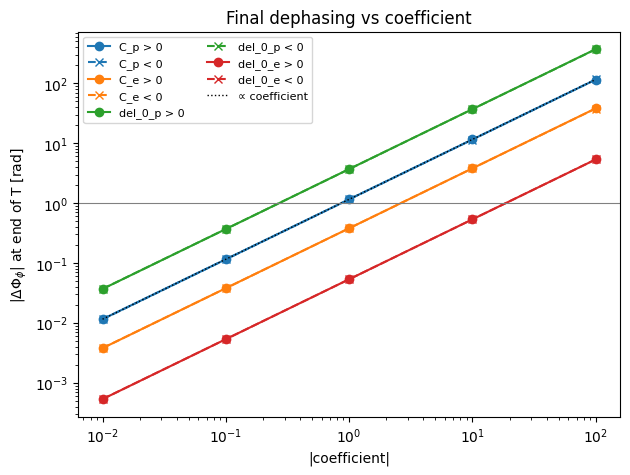

sign check (should be opposite):
  C_p     : +1 -> -1.156e+00 rad,  -1 -> +1.156e+00 rad
  C_e     : +1 -> -3.801e-01 rad,  -1 -> +3.801e-01 rad
  del_0_p : +1 -> +3.697e+00 rad,  -1 -> -3.693e+00 rad
  del_0_e : +1 -> +5.358e-02 rad,  -1 -> -5.361e-02 rad


In [31]:
scan_values = np.array([1e-2, 1e-1, 1.0, 1e1, 1e2])

def final_dephasing(add_args):
    """Delta Phi_phi (deviation - GR) at the last common time."""
    return dephasing(gr, run(add_args))[3][-1]

# final dephasing for +value and -value of each coefficient
scan = {name: {sign: [final_dephasing(dev_args(**{name: s * v})) for v in scan_values]
               for sign, s in [("+", 1), ("-", -1)]}
        for name in coeffs}

fig, ax = plt.subplots(figsize=(7, 5))
for name, c in zip(coeffs, ["C0", "C1", "C2", "C3"]):
    ax.loglog(scan_values, np.abs(scan[name]["+"]), "o-", color=c, label=f"{name} > 0")
    ax.loglog(scan_values, np.abs(scan[name]["-"]), "x--", color=c, label=f"{name} < 0")
ax.loglog(scan_values, scan_values * np.abs(scan["C_p"]["+"][2]), "k:", lw=1, label="∝ coefficient")
ax.axhline(1.0, color="grey", lw=0.8)
ax.set(xlabel="|coefficient|", ylabel=r"$|\Delta\Phi_\phi|$ at end of T [rad]", title="Final dephasing vs coefficient")
ax.legend(fontsize=8, ncol=2)
plt.show()

print("sign check (should be opposite):")
for name in coeffs:
    print(f"  {name:8s}: +1 -> {scan[name]['+'][2]:+.3e} rad,  -1 -> {scan[name]['-'][2]:+.3e} rad")

A handy number: in the linear regime, the coefficient that gives a **1 rad** dephasing over $T$ is a rough threshold for detectability. It is also where a Fisher-matrix analysis starts to become meaningful. Anything well below that value leaves no measurable imprint on this source.

In [32]:
# linear regime: dephasing per unit coefficient, from the coefficient = 1 run
for name in coeffs:
    slope = abs(scan[name]["+"][2])
    print(f"{name:8s}: {slope:.3e} rad per unit  ->  1 rad at |{name}| ~ {1 / slope:.3g}")

C_p     : 1.156e+00 rad per unit  ->  1 rad at |C_p| ~ 0.865
C_e     : 3.801e-01 rad per unit  ->  1 rad at |C_e| ~ 2.63
del_0_p : 3.697e+00 rad per unit  ->  1 rad at |del_0_p| ~ 0.27
del_0_e : 5.358e-02 rad per unit  ->  1 rad at |del_0_e| ~ 18.7


### 4.3 Deviations vs the 1PA terms

All four deviations are $\mathcal{O}(\eta)$, the same order as the PN-approximated 1PA terms. A useful comparison is therefore the dephasing caused by the **whole 1PA contribution** (1PA and 2PA switched on vs off, no deviation). This shows how large a deviation must be before it competes with physics that is already in the model. It also shows why neglecting 1PA in the template can bias the inferred deviation parameters.

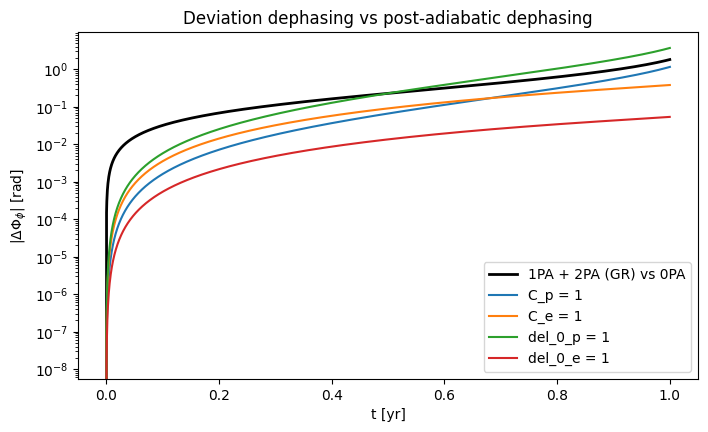

In [33]:
# dephasing caused by the post-adiabatic terms themselves: GR with 1PA+2PA vs pure 0PA
no_pa = run([chi2, False, evolve_primary, False, False])
t_c, _, _, dphi_pa, _ = dephasing(no_pa, gr)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_c / YRSID_SI, np.abs(dphi_pa), "k", lw=2, label="1PA + 2PA (GR) vs 0PA")
for label, out in dev_runs.items():
    t_d, _, _, dphi, _ = dephasing(gr, out)
    ax.plot(t_d / YRSID_SI, np.abs(dphi), label=label)
ax.set(xlabel="t [yr]", ylabel=r"$|\Delta\Phi_\phi|$ [rad]", yscale="log",
       title="Deviation dephasing vs post-adiabatic dephasing")
ax.legend()
plt.show()

- gives a sense of the result we were to use the deviation model to fit a GR signal. The dephasing caused by the post-adiabatic terms themselves is significant, and any deviation from GR would need to be distinguishable from this effect.

## 6. Effect on waveforms

`SuperKludgeWaveform` passes `add_args` to the trajectory, so a deviation is just extra arguments to the waveform (and to `ResponseWrapper`) call. The amplitudes remain adiabatic, so the deviation enters only through the phases.

We reuse the TDI generator `sk_tdi`, the GR signal `tdi_gr` and the inner product `ip` from Section 0.1, and compute the **noise-weighted mismatch** $1 - \langle h_{\rm GR}|h_{\rm dev}\rangle / \sqrt{\langle h_{\rm GR}|h_{\rm GR}\rangle\langle h_{\rm dev}|h_{\rm dev}\rangle}$ for a range of `C_p`. For small dephasing the mismatch scales roughly as $\Delta\Phi^2$, i.e. quadratically in the coefficient.

This needs the compiled FEW backend (GPU node / singularity container).

C_p =     1.0: mismatch = 4.790e-01
C_p =    10.0: mismatch = 1.184e+00
C_p =   100.0: mismatch = 1.007e+00
C_p =  1000.0: mismatch = 1.121e+00


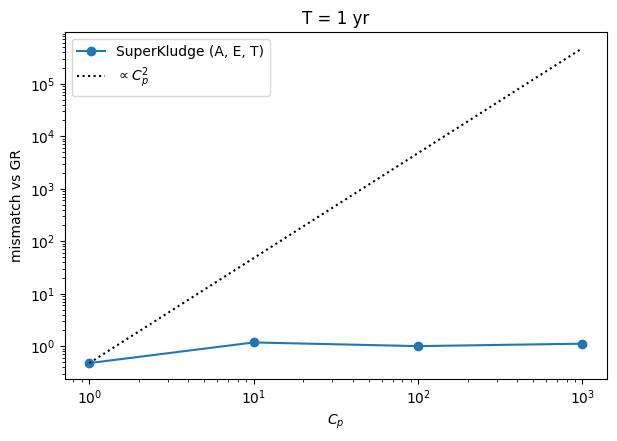

In [34]:
def mismatch(h1, h2):
    """1 - noise-weighted overlap, summed over A, E, T."""
    return 1 - ip(h1, h2) / np.sqrt(ip(h1, h1) * ip(h2, h2))

C_values = [1.0, 10.0, 100.0, 1000.0]
mismatches = []
for C in C_values:
    tdi_dev = xp.asarray(sk_tdi(*params_resp, *dev_args(C_p=C)))   # same source, C_p switched on
    mismatches.append(mismatch(tdi_gr, tdi_dev))
    print(f"C_p = {C:7.1f}: mismatch = {mismatches[-1]:.3e}")

plt.figure(figsize=(7, 4.5))
plt.loglog(C_values, mismatches, "o-", label="SuperKludge (A, E, T)")
plt.loglog(C_values, mismatches[0] * np.array(C_values) ** 2, "k:", label=r"$\propto C_p^2$")
plt.xlabel(r"$C_p$"); plt.ylabel("mismatch vs GR"); plt.title(f"T = {T_resp} yr")
plt.legend(); plt.show()

## 7. Systematic bias:  Levenberg–Marquardt

This section shows how the deviation parameters are used in the systematics study (`~/EMRI_CV_bias`, see `lm_markdown.md` and `AGENTS.md` there).

**Setup.** We inject a **1PA** SuperKludge signal $s$ and fit it with a deliberately incomplete **0PA** template $h(\theta)$ that is also given the two deviation parameters. Everything is noise-free, so the residual $s - h$ is pure systematics. The questions are:
* How far is the best fit $\hat\theta$ from the injection $\theta_{\rm true}$? This is the systematic bias, which we compare with the statistical error $\sigma$.
* Does the best fit need a non-zero deviation? If so, the deviation is **mimicking** the missing post-adiabatic physics, which would look like a false violation of GR.

### 7.1 Definitions

All quantities are evaluated at the current point $\theta$, with the noise-weighted inner product of Section 0.1:

$$
\langle a|b\rangle = 4\,\mathrm{Re}\sum_\alpha \int_{f_{\min}}^{f_{\rm Nyq}} \frac{\tilde a_\alpha^*(f)\,\tilde b_\alpha(f)}{S_\alpha(f)}\,df, \qquad f_{\min} = 10^{-5}\ \mathrm{Hz}.
$$

| Symbol | Definition | Meaning |
|---|---|---|
| $r(\theta)$ | $s - h(\theta)$ | residual |
| $\Gamma_{ij}(\theta)$ | $\langle \partial_i h \mid \partial_j h\rangle$ | Fisher matrix |
| $g_i(\theta)$ | $\langle \partial_i h \mid r\rangle$ | CV gradient |
| $\chi^2(\theta)$ | $\langle r \mid r\rangle$ | cost ($\approx 2\,\mathrm{SNR}^2 (1-\mathcal O)$) |
| $\mathcal O(\theta)$ | $\langle s|h\rangle/\sqrt{\langle s|s\rangle\langle h|h\rangle}$ | overlap |
| $\sigma_i(\theta)$ | $\sqrt{\lvert(\Gamma^{-1})_{ii}\rvert}$ | Fisher $1\sigma$ |

The derivatives $\partial_i h$ come from **StableEMRIFisher** (`deriv_type="stable"`). The finite-difference step sizes are re-optimised every `RECOMPUTE_DELTAS_EVERY` iterations.

### 7.2 From one CV step to an LM climb

The Cutler–Vallisneri bias $\Delta\theta = \Gamma^{-1} g$ is exactly **one Gauss–Newton step** on $\chi^2$. It is only accurate when the template is already close to the best fit. So we iterate it, with Levenberg–Marquardt damping to keep the steps safe:

$$
D_{ij} = \delta_{ij}\,(|\Gamma_{ii}| + 10^{-30}), \qquad \delta(\lambda) = (\Gamma + \lambda D)^{-1}\, g.
$$

* $\lambda \to 0$: $\delta = \Gamma^{-1} g$, the bare CV / Gauss–Newton step.
* $\lambda \to \infty$: $\delta \approx \lambda^{-1} D^{-1} g$, a short, scaled steepest-descent step.

**Choosing $\lambda$ (Nielsen gain ratio).** The quadratic model $\chi^2(\theta+\delta) \approx \chi^2 - 2\delta^T g + \delta^T\Gamma\delta$ predicts a decrease $L(\delta) = \delta^T(g + \lambda D\delta)$. We compare it with the actual decrease $A(\delta) = \chi^2(\theta) - \chi^2(\theta+\delta)$ through $\rho = A/L$:

* **accept** ($\rho > 0$): $\theta \leftarrow \theta + \delta$, $\lambda \leftarrow \lambda\,\max\!\left(\tfrac13,\, 1-(2\rho-1)^3\right)$, $\nu \leftarrow 2$.
  $\rho = 1$ gives $\lambda/3$ (the model is good, so move towards pure CV). $\rho \to 0^+$ gives $2\lambda$ (damp harder).
* **reject** ($\rho \le 0$, or $\Gamma+\lambda D$ is singular): keep $\theta$ and retry with $\lambda \leftarrow \lambda\nu$, $\nu \leftarrow 2\nu$ (i.e. $\times2, \times8, \times64, \dots$). After `MAX_INNER` failed retries the climb stops.

**Termination** (any one): $\mathcal O > $ `OVERLAP_TARGET`, relative decrease $A/\chi^2 <$ `REL_TOL`, or `LM_MAX_ITERS` iterations.

### 7.3 The flat-ridge problem and the Nelder–Mead escape

If $g_i \approx 0$ for the deviation parameters, as happens when starting exactly at $C_p = C_e = 0$ at the 0PA best fit, then $\delta_i \approx 0$ for **every** $\lambda$, and the climb never leaves $\mathrm{dev}=0$. Changing $\lambda$ does not help. Each run is therefore

**LM climb → (if it stalls below the overlap target) one Nelder–Mead escape in $\sigma$-scaled coordinates → LM climb again.**

Also note:
* **0PA is nested inside 0PA+deviation** (at dev = 0), so a deviation fit that ends *worse* than the 0PA fit is always a convergence artifact. Fix it by re-seeding, not by changing $\lambda$.
* **The choice of seed matters.** We can use nealder-mead or DE for initial SEEDing if injection points do not work

### 7.4 Implementation

The code below is a compact, self-contained version of the `EMRI_CV_bias` scripts (`build_context → lm_climb → nm_refine → cv_from`). It uses the response settings from Section 0.1 and **should be run on the GPU node** (`use_gpu = True`). Each LM iteration computes a full set of stable derivatives, so a climb takes minutes to hours.

To make the example converge from the injection, we use a **short observation ($T = 0.25$ yr)**. The 0PA–1PA dephasing is then small

In [35]:
# --- controls (house defaults from EMRI_CV_bias) ---------------------------------------
F_MIN = 1e-5                      # [Hz] lower limit of the inner product
NDELTA = 12                       # size of the StableEMRIFisher step-size search
RECOMPUTE_DELTAS_EVERY = 5        # re-optimise the finite-difference steps every N iterations
OVERLAP_TARGET = 0.9999999999     # stop once the overlap exceeds this
LAMBDA0, LM_MAX_ITERS, MAX_INNER, REL_TOL = 1e-2, 150, 30, 1e-9
NM_MAXITER, NM_STEP = 1000, 2.0   # Nelder-Mead escape: max iterations, simplex size in units of sigma

# --- which deviation the template gets: dev_1, dev_2 ------------------------------------
DEV_MODEL = "PN"   # "PN": (C_p, C_e)     "simple": (del_0_p, del_0_e)

def dev_tail(dev_1, dev_2):
    """add_args slots 5-8 = [C_p, C_e, del_0_p, del_0_e] for the chosen model."""
    return [dev_1, dev_2, 0.0, 0.0] if DEV_MODEL == "PN" else [0.0, 0.0, dev_1, dev_2]

def dev_apa(dev_1, dev_2):
    """Same slots as a dict for StableEMRIFisher (it appends add_param_args in dict ORDER)."""
    keys = ["dev_1", "dev_2", "del_0_p", "del_0_e"] if DEV_MODEL == "PN" else ["C_p", "C_e", "dev_1", "dev_2"]
    return dict(zip(keys, dev_tail(dev_1, dev_2)))

# --- injection: 1PA GR signal, short T so that the injection is a usable seed ------------
T_lm, dt_lm = 0.25, 10.0
param_names_14 = ["m1", "m2", "a", "p0", "e0", "xI0", "dist", "qS", "phiS",
                  "qK", "phiK", "Phi_phi0", "Phi_theta0", "Phi_r0"]
params_to_infer = ["m1", "m2", "a", "p0", "e0", "qS", "phiS", "Phi_phi0", "Phi_r0", "dev_1", "dev_2"]

p0_lm = get_p_at_t(traj, T_lm, [m1, m2, a, e0, x0, chi2, True, False, False, False]) + 0.1
signal_param = dict(m1=m1, m2=m2, a=a, p0=p0_lm, e0=e0, xI0=x0, dist=dist, qS=qS, phiS=phiS,
                    qK=qK, phiK=phiK, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
                    dev_1=0.0, dev_2=0.0)
theta_true = np.array([signal_param[n] for n in params_to_infer])
print("injection:", {n: float(v) for n, v in zip(params_to_infer, theta_true)})

injection: {'m1': 1000000.0, 'm2': 10.0, 'a': 0.9, 'p0': 5.184786979342342, 'e0': 0.2, 'qS': 1.0471975511965976, 'phiS': 0.7853981633974483, 'Phi_phi0': 0.1, 'Phi_r0': 0.3, 'dev_1': 0.0, 'dev_2': 0.0}


In [36]:
def highpass_clip(w, dt, fmin):
    """Remove frequencies below fmin."""
    f = xp.fft.rfftfreq(w.shape[-1], dt)
    return xp.fft.irfft(xp.fft.rfft(w, axis=-1) * (f >= fmin), n=w.shape[-1], axis=-1)

def build_context(sp, T, dt, chi2):
    """Signal s, inner product, overlap, chi^2 and Fisher derivatives for one injection."""
    wresp = make_tdi_generator(T, dt)                    # SuperKludge -> A, E, T (Section 0.1)

    def wave_args(vec, evolve_1pa, deviation_on):
        """14 waveform parameters (fixed ones from sp, inferred ones from vec) + add_args."""
        p = {**sp, **dict(zip(params_to_infer, vec))}
        return [p[n] for n in param_names_14] + [
            chi2, evolve_1pa, False, False, deviation_on, *dev_tail(vec[9], vec[10])]

    def make0(vec):                                      # template: 0PA + deviation
        return xp.asarray(wresp(*wave_args(vec, False, True)))

    true_vec = np.array([sp[n] for n in params_to_infer])
    s = highpass_clip(xp.asarray(wresp(*wave_args(true_vec, True, False))), dt, F_MIN)  # signal: 1PA, GR

    psd = xp.asarray(generate_PSD(waveform=s, dt=dt, noise_PSD=get_sensitivity,
                                  channels=channels, noise_kwargs=noise_kwargs, use_gpu=use_gpu))
    fmask = (xp.fft.rfftfreq(s.shape[-1], dt) > F_MIN)[1:]

    def ip(a, b):
        return to_float(inner_product(a, b, PSD=psd, dt=dt, freq_mask=fmask, use_gpu=use_gpu))

    def ov(vec):
        h = make0(vec)
        return ip(s, h) / np.sqrt(ip(s, s) * ip(h, h))

    def chi2r(vec):
        try:
            r = s - make0(vec)
            return ip(r, r)
        except Exception:                                # e.g. trajectory off the grid
            return 1e30

    sef = StableEMRIFisher(
        waveform_class=SuperKludgeWaveform,
        waveform_class_kwargs=dict(sum_kwargs=dict(pad_output=True, odd_len=True)),
        waveform_generator=GenerateEMRIWaveform, waveform_generator_kwargs=dict(return_list=False),
        ResponseWrapper=ResponseWrapper, ResponseWrapper_kwargs=response_kwargs(T, dt),
        noise_model=get_sensitivity, noise_kwargs=noise_kwargs, channels=channels,
        T=T, dt=dt, deriv_type="stable", der_order=6, Ndelta=NDELTA,
        use_gpu=use_gpu, plunge_check=True, return_derivatives=True,
        stats_for_nerds=False, stability_plot=False)

    def fisher_derivs(vec, deltas):
        """Fisher matrix, derivatives dh/dtheta_i, and the finite-difference steps used."""
        p = {**sp, **dict(zip(params_to_infer, vec))}
        apa = {"chi2": chi2, "evolve_1PA": False, "evolve_primary": False,
               "evolve_2PA": False, "deviation_included": True, **dev_apa(vec[9], vec[10])}
        F = sef(wave_params={n: p[n] for n in param_names_14}, param_names=params_to_infer,
                add_param_args=apa, deltas=deltas, live_dangerously=False, stability_plot=False,
                der_order=8, Ndelta=(NDELTA if deltas is None else None))
        return np.asarray(F[-1], dtype=float), xp.asarray(F[0]), sef.deltas

    return dict(make0=make0, ov=ov, chi2r=chi2r, ip=ip, s=s,
                fisher_derivs=fisher_derivs, snr=float(np.sqrt(ip(s, s))))

In [37]:
def lm_climb(ctx, theta0, tag=""):
    """Iterated CV (Gauss-Newton) step with Levenberg-Marquardt damping and Nielsen lambda updates."""
    ip, s, make0, chi2r = ctx["ip"], ctx["s"], ctx["make0"], ctx["chi2r"]
    cur = np.array(theta0, dtype=float)
    npar = len(cur)
    lam, nu, deltas, sigma, history = LAMBDA0, 2.0, None, np.ones(npar), []

    for it in range(LM_MAX_ITERS):
        if it % RECOMPUTE_DELTAS_EVERY == 0:
            deltas = None                                          # re-optimise the steps
        G, dH, new_deltas = ctx["fisher_derivs"](cur, deltas)      # Gamma_ij, dh/dtheta_i
        deltas = deltas or new_deltas

        h = make0(cur)
        r = s - h                                                  # residual
        g = np.array([ip(dH[j], r) for j in range(npar)])          # CV gradient
        sigma = np.sqrt(np.abs(np.diag(fishinv(cur[0], G, index_of_M=0))))
        c0 = ip(r, r)                                              # chi^2
        ovc = ip(s, h) / np.sqrt(ip(s, s) * ip(h, h))
        history.append((it, lam, ovc, c0))
        if ovc > OVERLAP_TARGET:
            break

        # damped step: try lambda, lambda*nu, ... until chi^2 actually decreases
        D = np.abs(np.diag(G)) + 1e-30                             # Marquardt scaling
        ok, rel = False, 0.0
        for _ in range(MAX_INNER):
            try:
                delta = np.linalg.solve(G + lam * np.diag(D), g)
            except np.linalg.LinAlgError:
                lam, nu = lam * nu, nu * 2.0
                continue
            predicted = float(delta @ (g + lam * D * delta))       # L(delta)
            actual = c0 - chi2r(cur + delta)                       # A(delta)
            rho = actual / predicted if predicted > 0 else -1.0    # gain ratio
            if rho > 0:                                            # accept, relax damping
                lam, nu = lam * max(1 / 3, 1 - (2 * rho - 1) ** 3), 2.0
                rel, ok = actual / c0, True
                break
            lam, nu = lam * nu, nu * 2.0                           # reject, damp harder

        print(f"    LM{tag} it {it:>3} lam={lam:.1e} ov={ovc:.10f} chi2={c0:.3e} rel={rel:.1e}")
        if not ok:
            break
        cur = cur + delta
        if rel < REL_TOL:
            break
    return cur, ctx["ov"](cur), sigma, history


def nm_refine(ctx, theta0, sigma, maxiter=NM_MAXITER):
    """Nelder-Mead escape in sigma-scaled coordinates; kept only if the overlap improves."""
    n = len(theta0)
    simplex = np.vstack([np.zeros(n)] + [NM_STEP * np.eye(n)[i] for i in range(n)])
    res = minimize(lambda x: ctx["chi2r"](theta0 + x * sigma), np.zeros(n), method="Nelder-Mead",
                   options=dict(initial_simplex=simplex, maxiter=maxiter,
                                xatol=1e-4, fatol=1e-4, adaptive=True))
    cand = theta0 + res.x * sigma
    ov0, ov1 = ctx["ov"](theta0), ctx["ov"](cand)
    print(f"    NM  nfev={res.nfev} ov {ov0:.10f} -> {ov1:.10f} (accepted={ov1 > ov0})")
    return cand if ov1 > ov0 else theta0


def cv_from(ctx, label, start):
    """LM climb -> (if stalled) NM escape -> LM climb."""
    print(f"--- start = {label} (overlap {ctx['ov'](start):.10f}) ---")
    theta, ov1, sigma, hist = lm_climb(ctx, start, tag=f" {label}#1")
    if ov1 < OVERLAP_TARGET:
        theta = nm_refine(ctx, theta, sigma)
        theta, ov1, sigma, hist2 = lm_climb(ctx, theta, tag=f" {label}#2")
        hist += hist2
    return dict(params=theta, sigma=sigma, ov_start=ctx["ov"](start), ov_final=ov1,
                chi2=ctx["chi2r"](theta), history=hist)

### 7.5 Run: 1PA injection, 0PA + deviation template

We start at the injection with the deviation at zero. At $T=0.25$ yr the injection is close to the best fit, so this seed works here. Section 7.3 explains why it does not for long signals.

In [38]:
ctx = build_context(signal_param, T_lm, dt_lm, chi2)
print(f"SNR = {ctx['snr']:.2f}")

start = time.time()
fit = cv_from(ctx, "from_injection", theta_true)
print(f"done in {(time.time() - start) / 60:.1f} min: overlap {fit['ov_start']:.10f} -> "
      f"{fit['ov_final']:.10f}, chi2 = {fit['chi2']:.3e}")

SNR = 155.13
--- start = from_injection (overlap 0.1059946432) ---
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
Computing SNR for parameters: (np.float64(1000000.0), np.float64(10.0), np.float64(0.9), np.float64(5.184786979342342), np.float64(0.2), 1.0, 1.0, np.float64(1.0471975511965976), np.float64(0.7853981633974483), 0.6283185307179586, 0.5235987755982988, np.float64(0.1), 0.2, np.float64(0.3), 0.6, False, False, False, True, np.float64(0.0), np.float64(0.0), 0.0, 0.0)
Waveform Generated. SNR: 156.24541743634686
calculating stable deltas...
minimum relative error is greater than 1% for dev_2. Fisher may be unstable!
Time taken to compute stable deltas is 24.212307929992676 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.0808820724487305 seconds
    LM from_injection#1 it   0 lam=3.9e-03 ov=0.1059946432 chi2=4.303e+04 rel=2.8e-01
Body is not plunging, Fisher should

    param        injected        best fit         bias       sigma |bias|/sigma
       m1         1000000       999956.19   -4.381e+01   2.579e+02         0.17
       m2              10       9.9949175   -5.083e-03   1.505e-03         3.38
        a             0.9      0.90000367    3.669e-06   9.191e-05         0.04
       p0        5.184787       5.1848013    1.428e-05   6.045e-04         0.02
       e0             0.2      0.20008559    8.559e-05   2.568e-04         0.33
       qS       1.0471976       1.0474517    2.541e-04   5.606e-03         0.05
     phiS      0.78539816      0.78547501    7.685e-05   7.223e-03         0.01
 Phi_phi0             0.1     0.095018952   -4.981e-03   3.288e-02         0.15
   Phi_r0             0.3      0.31593181    1.593e-02   4.096e-02         0.39
    dev_1               0      -114.98592   -1.150e+02   9.971e+01         1.15
    dev_2               0     -0.32929145   -3.293e-01   3.556e+01         0.01

best-fit deviation (PN): dev_1 = -115, 

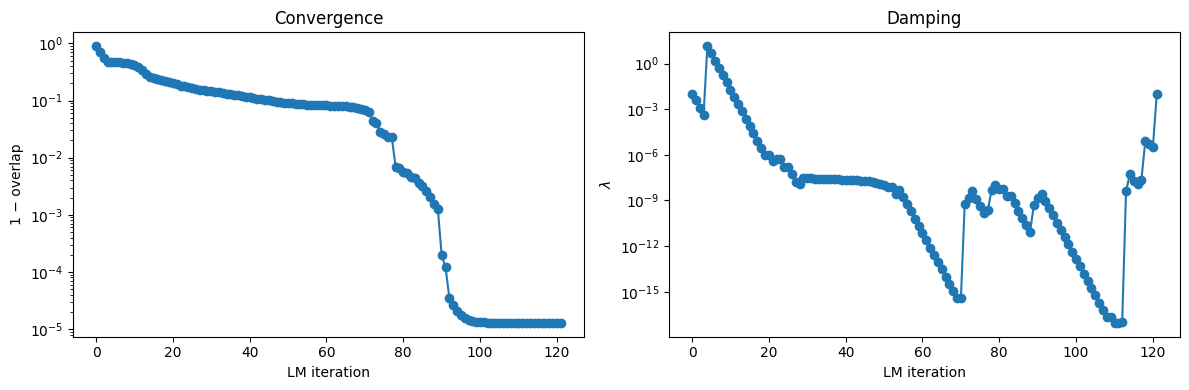

In [40]:
# systematic bias vs statistical error
bias = fit["params"] - theta_true
print(f"{'param':>9} {'injected':>15} {'best fit':>15} {'bias':>12} {'sigma':>11} {'|bias|/sigma':>12}")
for n, tv, bf, b, sg in zip(params_to_infer, theta_true, fit["params"], bias, fit["sigma"]):
    print(f"{n:>9} {tv:>15.8g} {bf:>15.8g} {b:>12.3e} {sg:>11.3e} {abs(b) / sg:>12.2f}")

print(f"\nbest-fit deviation ({DEV_MODEL}): dev_1 = {fit['params'][9]:+.4g}, dev_2 = {fit['params'][10]:+.4g}")
print("optimised point [" + ", ".join(params_to_infer) + "]:")
print("[" + ", ".join(f"{x:.8e}" for x in fit["params"]) + "]")

# convergence history
_, lam, ovs, _ = np.array(fit["history"]).T
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].semilogy(1 - ovs, "o-"); axs[0].set(xlabel="LM iteration", ylabel="1 − overlap", title="Convergence")
axs[1].semilogy(lam, "o-"); axs[1].set(xlabel="LM iteration", ylabel=r"$\lambda$", title="Damping")
plt.tight_layout(); plt.show()

**Reading the result:**
* $|\mathrm{bias}|/\sigma > 1$ means that neglecting 1PA in the template biases that parameter beyond the statistical error.
* A best-fit `dev_1` / `dev_2` far from zero, together with a clear gain in overlap over a 0PA-only fit, means the deviation is absorbing the missing 1PA physics. That is a false "GR violation".
* To measure how much the deviation helps, repeat the fit with the deviation fixed at zero (0PA only). Compare the mismatches $(1-\mathcal O_{0\rm PA})/(1-\mathcal O_{\rm dev})$, and set `DEV_MODEL = "simple"` to compare the two families.

## Summary

* **Response (Section 0.1):** `ResponseWrapper` turns the SuperKludge waveform into the TDI channels A, E, T. The noise-weighted inner product over these channels is used for mismatches and for the bias study. Check that the T-channel SNR is ≈ 0 (no aliasing).
* **Two deviation families**, both switched on by `deviation_included = True` (index 4):
  * additive `C_p`, `C_e` (indices 5, 6): terms with the Peters–Mathews eccentricity dependence and an extra $\eta\,p^{-1/2}$. Positive values **slow** the inspiral.
  * multiplicative `del_0_p`, `del_0_e` (indices 7, 8): a uniform fractional change $\eta\,\delta_0$ of the 0PA $\dot p$ or $\dot e$. Positive values **speed up** the inspiral.
* All four are $\mathcal{O}(\eta)$ relative to the adiabatic fluxes, the same order as the 1PA terms. The dephasing they cause should therefore be compared with the 1PA dephasing (Section 4.3), which is also the main source of systematic bias if a template omits 1PA.
* With all coefficients zero, or with the switch off, the model is exactly GR SuperKludge (Section 2).
* In the linear regime the dephasing scales linearly with the coefficient and the mismatch quadratically. Section 4.2 gives, for each coefficient, the value that produces a 1 rad dephasing over $T$ for this source.
* $p_0$ from `get_p_at_t` depends on the deviation (Section 5). Decide whether you are comparing at fixed $p_0$ or at fixed plunge time.

* **Bias studies (Section 7):** inject 1PA, fit 0PA + deviation, and iterate the CV step with LM damping (LM → NM escape → LM). A non-zero best-fit deviation means the deviation mimics the missing post-adiabatic physics. Beware the flat ridge at dev = 0 and seed from more than one point.

**Next:** the production version of Section 7, over EMRI/IMRI grids, is in `~/EMRI_CV_bias` (read its `AGENTS.md` first). `environmental_models.ipynb` covers the environmental-effect models.